# =====================================================================
#  ARIMAX(2)-GARCH(1,1) vs nested ARIMA-GARCH vs Random Walk
#  Leakage-free rolling-window forecast evaluation for IDR/USD (JISDOR)
# ---------------------------------------------------------------------

Key anti-leakage design:
* The model orders (AR(2), GARCH(1,1)) are FROZEN in advance; only the coefficients are re-estimated on each window.
* Each window uses ONLY observations up to the forecast origin `o`.
* For multi-step (h > 1) forecasts the exogenous variables are held at their last known level at the origin, so their future first differences are ZERO. No future macro value (FFR/BI/CPI) is ever read. This is exactly the information a real-time forecaster has.
# =====================================================================

In [26]:
import warnings; warnings.filterwarnings("ignore")
!pip install -q arch          # pin your version for exact reproducibility, e.g. arch==8.0.0
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from arch.univariate import ARX, GARCH
from arch.unitroot import ADF, PhillipsPerron
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.api import VAR

np.random.seed(42)
rng = np.random.default_rng(42)   # for the interval simulations

# ---------------------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------------------

In [27]:
DATA_FILE = "merged_data_clean.csv"          # columns: date, fx, ffr, bi, cpi
df = pd.read_csv(DATA_FILE, parse_dates=["date"])
df = df.set_index("date").sort_index()

# ---------------------------------------------------------------------
# 2. Preprocessing: stationary transforms
fx  -> log-return (in %), I(0)
exogenous (I(1)) -> first difference
# ---------------------------------------------------------------------

In [29]:
df["logret"] = np.log(df["fx"]).diff() * 100.0
for c in ["ffr", "bi", "cpi"]:
    df["d_" + c] = df[c].diff()

data = df.dropna().copy()
y    = data["logret"].to_numpy()
Xz   = data[["d_ffr", "d_bi", "d_cpi"]].to_numpy()
lvl  = data["fx"].to_numpy()
logp = np.log(lvl)                                   # for the ECM model
Wlvl = data[["ffr", "cpi", "bi"]].to_numpy(float)    # macro levels for cointegration
n    = len(data)

print("=" * 70); print("DATA SUMMARY"); print("=" * 70)
print(f"Aligned observations : {n}")
print(f"Sample period        : {data.index[0].date()}  to  {data.index[-1].date()}")
print(f"Max fx               : {lvl.max():.0f}  on {data.index[int(np.argmax(lvl))].date()}")
print(f"Min fx               : {lvl.min():.0f}  on {data.index[int(np.argmin(lvl))].date()}")

DATA SUMMARY
Aligned observations : 2003
Sample period        : 2018-04-03  to  2026-07-27
Max fx               : 18171  on 2026-06-08
Min fx               : 13612  on 2020-01-27


# ---------------------------------------------------------------------
# 3. Stationarity tests (Table 1): ADF & PP on level and first difference
# ---------------------------------------------------------------------

In [30]:
print("=" * 70); print("TABLE I  Unit-root tests (p-values)"); print("=" * 70)
print(f"{'Series':<18}{'ADF lvl':>9}{'PP lvl':>9}{'ADF d':>9}{'PP d':>9}{'  Order':>8}")

def unit_root_row(level_series, name):
    lv = level_series.dropna().to_numpy(); dv = np.diff(lv)
    adf_l = ADF(lv).pvalue; pp_l = PhillipsPerron(lv).pvalue
    adf_d = ADF(dv).pvalue; pp_d = PhillipsPerron(dv).pvalue
    order = "I(1)" if (adf_l > 0.05 and adf_d < 0.05) else "check"
    print(f"{name:<18}{adf_l:>9.4f}{pp_l:>9.4f}{adf_d:>9.4f}{pp_d:>9.4f}{order:>8}")

unit_root_row(np.log(df["fx"]), "log(fx)")
for c, nm in [("ffr", "Federal Funds"), ("bi", "BI Rate"), ("cpi", "CPI")]:
    unit_root_row(df[c], nm)

TABLE I  Unit-root tests (p-values)
Series              ADF lvl   PP lvl    ADF d     PP d   Order
log(fx)              0.6641   0.6885   0.0000   0.0000    I(1)
Federal Funds        0.8531   0.8571   0.0000   0.0000    I(1)
BI Rate              0.4281   0.7380   0.0000   0.0000    I(1)
CPI                  0.9669   0.9749   0.0000   0.0000    I(1)


# 4. Johansen cointegration test\nLog exchange rate + three exogenous variables in levels.

In [31]:
joh = pd.DataFrame({"logX": np.log(df["fx"]), "ffr": df["ffr"],
                    "bi": df["bi"], "cpi": df["cpi"]}).dropna()
p = max(int(VAR(joh).select_order(maxlags=10).aic), 1)
res = coint_johansen(joh, det_order=0, k_ar_diff=p - 1)

print("=" * 70); print("JOHANSEN COINTEGRATION TEST"); print("=" * 70)
print(f"Observations : {len(joh)}    Lag (AIC) : {p}  (k_ar_diff = {p-1})")
print(f"\n{'r':<4}{'trace':>10}{'cv95':>10}   decision (5%)")
for i, (s, c) in enumerate(zip(res.lr1, res.cvt[:, 1])):
    print(f"{i:<4}{s:>10.2f}{c:>10.2f}   {'reject H0' if s > c else 'fail to reject'}")
r = 0
for s, c in zip(res.lr1, res.cvt[:, 1]):
    if s > c: r += 1
    else: break
print(f"\nCointegration rank (trace, 5%): r = {r}")

JOHANSEN COINTEGRATION TEST
Observations : 2004    Lag (AIC) : 2  (k_ar_diff = 1)

r        trace      cv95   decision (5%)
0        70.14     47.85   reject H0
1        13.11     29.80   fail to reject
2         1.34     15.49   fail to reject
3         0.02      3.84   fail to reject

Cointegration rank (trace, 5%): r = 1


#----------------------------------------------------------------------
# 5. ARIMAX(2)-GARCH(1,1) estimates (Table II)
## 5.1 Representative window + residual diagnostics
Uses the final full window as the representative window
#----------------------------------------------------------------------

In [32]:
WINDOW = 1000
rep = slice(n - WINDOW, n)
mrep = ARX(y[rep], lags=[1, 2], x=Xz[rep], rescale=False)
mrep.volatility = GARCH(p=1, o=0, q=1)
rres = mrep.fit(disp="off")

print("=" * 70); print("Representative window (last 1000 obs) - full estimates"); print("=" * 70)
print(rres.summary())

zr = np.asarray(rres.std_resid); zr = zr[~np.isnan(zr)]
lb = acorr_ljungbox(zr, lags=[20], return_df=True)["lb_pvalue"].iloc[0]
arch_lm_p = het_arch(zr, nlags=12)[1]; jb_p = stats.jarque_bera(zr)[1]
print("\nResidual diagnostics (standardized residuals):")
print(f"  Ljung-Box(20) p = {lb:.3f}    ARCH-LM p = {arch_lm_p:.3f}    Jarque-Bera p = {jb_p:.3g}")

Representative window (last 1000 obs) - full estimates
                          AR-X - GARCH Model Results                          
Dep. Variable:                      y   R-squared:                       0.025
Mean Model:                      AR-X   Adj. R-squared:                  0.020
Vol Model:                      GARCH   Log-Likelihood:               -326.507
Distribution:                  Normal   AIC:                           671.015
Method:            Maximum Likelihood   BIC:                           715.167
                                        No. Observations:                  998
Date:                Thu, Sep 17 2026   Df Residuals:                      992
Time:                        04:52:22   Df Model:                            6
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
Con

## 5.2 Cross-window coefficient distribution (right block of Table II) + Figure 6
Re-estimates the frozen ARIMAX(2)-GARCH(1,1) on every rolling window.

2003 obs -> 1004 rolling windows
  100/1004
  200/1004
  300/1004
  400/1004
  500/1004
  600/1004
  700/1004
  800/1004
  900/1004
  1000/1004


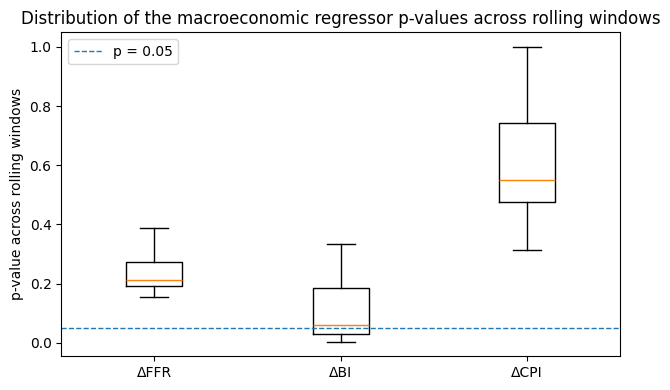

Macro regressors significant at 5% in 0.0-42.2% of windows (chance ~5%).


In [33]:
ALPHA = 0.05
n_windows = n - WINDOW + 1
print(f"{n} obs -> {n_windows} rolling windows")

rows, failed = [], 0
for i in range(n_windows):
    sl = slice(i, i + WINDOW)
    m = ARX(y[sl], lags=[1, 2], x=Xz[sl])          # true GARCH(1,1): o=0
    m.volatility = GARCH(p=1, o=0, q=1)
    try:
        r = m.fit(disp="off", cov_type="robust")
    except Exception:
        failed += 1; continue
    for name in r.params.index:
        rows.append({"param": name, "coef": float(r.params[name]), "pval": float(r.pvalues[name])})
    if (i + 1) % 100 == 0: print(f"  {i + 1}/{n_windows}")
if failed: print(f"WARNING: {failed} windows skipped (no convergence)")

long_df = pd.DataFrame(rows)
summary = (long_df.groupby("param")
           .agg(mean_coef=("coef", "mean"), sd_coef=("coef", "std"),
                pct_positive=("coef", lambda s: 100 * (s > 0).mean()),
                pct_sig=("pval", lambda s: 100 * (s < ALPHA).mean())))

# Figure 6: distribution of the macro-regressor p-values across rolling windows
EXOG, EXOG_LABELS = ["x0", "x1", "x2"], ["ΔFFR", "ΔBI", "ΔCPI"]
box_data = [long_df.loc[long_df["param"] == c, "pval"].values for c in EXOG]
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.boxplot(box_data, labels=EXOG_LABELS, showfliers=False)
ax.axhline(ALPHA, ls="--", lw=1, label=f"p = {ALPHA}")
ax.set_ylabel("p-value across rolling windows")
ax.set_title("Distribution of the macroeconomic regressor p-values across rolling windows")
ax.legend(); fig.tight_layout(); fig.savefig("figure6.png", dpi=200); plt.show()
macro_sig = summary.loc[EXOG, "pct_sig"]
print(f"Macro regressors significant at 5% in "
      f"{macro_sig.min():.1f}-{macro_sig.max():.1f}% of windows (chance ~5%).")

## 5.3 Combined Table II (representative window + cross-window)

In [34]:
LABELS = {"Const": "Constant", "y[1]": "logret(t-1)", "y[2]": "logret(t-2)",
          "x0": "ΔFFR", "x1": "ΔBI", "x2": "ΔCPI",
          "omega": "ω", "alpha[1]": "α1", "beta[1]": "β1"}
MEAN_EQ = ["Const", "y[1]", "y[2]", "x0", "x1", "x2"]; VAR_EQ = ["omega", "alpha[1]", "beta[1]"]
def fmt_p(p): return "<0.001" if p < 0.001 else f"{p:.3f}"
def make_row(name):
    return {"Parameter": LABELS[name],
            "Coef.": round(float(rres.params[name]), 4), "Std. err.": round(float(rres.std_err[name]), 4),
            "p-value": fmt_p(float(rres.pvalues[name])),
            "Mean": round(float(summary.loc[name, "mean_coef"]), 4), "SD": round(float(summary.loc[name, "sd_coef"]), 4),
            "% coef>0": round(float(summary.loc[name, "pct_positive"]), 1),
            "% windows p<0.05": round(float(summary.loc[name, "pct_sig"]), 1)}
table2 = pd.DataFrame([make_row(k) for k in MEAN_EQ + VAR_EQ]).set_index("Parameter")
print("=" * 90); print("TABLE II  ARIMAX(2)-GARCH(1,1) ESTIMATES, REPRESENTATIVE WINDOW AND CROSS-WINDOW"); print("=" * 90)
print("Mean Equation"); print(table2.loc[[LABELS[k] for k in MEAN_EQ]].to_string())
print("\nVariance Equation"); print(table2.loc[[LABELS[k] for k in VAR_EQ]].to_string())
print(f"\nNote: Returns in percent; N = {int(rres.nobs)}; log-likelihood = {rres.loglikelihood:.2f}; "
      f"AIC = {rres.aic:.2f}; BIC = {rres.bic:.2f}.")
table2.to_csv("table2.csv")

TABLE II  ARIMAX(2)-GARCH(1,1) ESTIMATES, REPRESENTATIVE WINDOW AND CROSS-WINDOW
Mean Equation
              Coef.  Std. err. p-value    Mean      SD  % coef>0  % windows p<0.05
Parameter                                                                         
Constant     0.0278     0.0102   0.006  0.0103  0.0096      74.3              22.0
logret(t-1)  0.1134     0.0345   0.001  0.1248  0.0152     100.0             100.0
logret(t-2) -0.1137     0.0356   0.001 -0.0657  0.0514      15.0              53.8
ΔFFR        -0.3617     0.2551   0.156 -0.2676  0.1461       4.8               0.0
ΔBI          0.3503     0.2830   0.216  0.5179  0.2068      96.2              42.2
ΔCPI         0.0892     0.1651   0.589  0.0544  0.0377      92.0               0.0

Variance Equation
            Coef.  Std. err. p-value    Mean      SD  % coef>0  % windows p<0.05
Parameter                                                                       
ω          0.0060     0.0037   0.104  0.0045  0.0016     100

# ---------------------------------------------------------------------
# 6. Rolling-window, leakage-free point forecasts
Builds the level-error dictionary `err` for all five models. Horizons h = 1, 5, 10, 20, 60.
## 6.1 Base loop: RW, ARIMA-GARCH, ARIMAX-GARCH
# ---------------------------------------------------------------------

In [35]:
H = [1, 5, 10, 20, 60]
err = {m: {h: [] for h in H} for m in ["arimax", "arima", "rw"]}
act = {h: [] for h in H}
exog_future = np.zeros(3)               # future macro diffs are unknown at the origin -> 0

for o in range(WINDOW - 1, n - 1):      # o = index of last in-sample observation
    tr = slice(o - WINDOW + 1, o + 1)
    ytr, Xtr = y[tr], Xz[tr]
    mx = ARX(ytr, lags=[1, 2], x=Xtr, rescale=False); mx.volatility = GARCH(p=1, o=0, q=1)
    px = mx.fit(disp="off").params.to_numpy(); cX, a1X, a2X, bX = px[0], px[1], px[2], px[3:6]
    m0 = ARX(ytr, lags=[1, 2], rescale=False); m0.volatility = GARCH(p=1, o=0, q=1)
    p0 = m0.fit(disp="off").params.to_numpy(); c0, a10, a20 = p0[0], p0[1], p0[2]
    for h in H:
        if o + h > n - 1: continue
        l1, l2, s = y[o], y[o - 1], 0.0
        for _ in range(h):
            rh = cX + a1X*l1 + a2X*l2 + bX @ exog_future; s += rh; l2, l1 = l1, rh
        lx = lvl[o] * np.exp(s / 100.0)
        l1, l2, s = y[o], y[o - 1], 0.0
        for _ in range(h):
            rh = c0 + a10*l1 + a20*l2; s += rh; l2, l1 = l1, rh
        l0 = lvl[o] * np.exp(s / 100.0)
        a = lvl[o + h]; act[h].append(a)
        err["arimax"][h].append(a - lx); err["arima"][h].append(a - l0); err["rw"][h].append(a - lvl[o])
    if (o - WINDOW + 2) % 200 == 0: print(f"  {o - WINDOW + 2}/{n - WINDOW}")
print("base loop done")

  200/1003
  400/1003
  600/1003
  800/1003
  1000/1003
base loop done


## 6.2 Random walk with drift

In [36]:
err["rw_drift"] = {h: [] for h in H}
for o in range(WINDOW - 1, n - 1):
    tr = slice(o - WINDOW + 1, o + 1)
    drift = np.mean(y[tr]) / 100.0                 # mean log-return in the window
    for h in H:
        if o + h > n - 1: continue
        err["rw_drift"][h].append(lvl[o] * np.exp(h * drift) - lvl[o + h])
print("rw_drift done")

rw_drift done


## 6.3 ARIMAX-ECM-GARCH
Engle-Granger long-run regression on each window's in-sample levels forms the equilibrium
error `z_{t-1}`; the mean equation adds it as a regressor with coefficient lambda.

In [37]:
def fit_ec_term(logp_win, Wlvl_win):
    D = np.column_stack([np.ones(len(logp_win)), Wlvl_win])
    coef, *_ = np.linalg.lstsq(D, logp_win, rcond=None)
    return coef[0], coef[1:], logp_win - D @ coef

err["arimax_ecm"] = {h: [] for h in H}
for o in range(WINDOW - 1, n - 1):
    tr = slice(o - WINDOW + 1, o + 1); ytr = y[tr]
    a_ec, b_ec, zw = fit_ec_term(logp[tr], Wlvl[tr])
    zlag = np.empty_like(zw); zlag[0] = 0.0; zlag[1:] = zw[:-1]
    ok = True
    try:
        me = ARX(ytr, lags=[1, 2], x=np.column_stack([Xz[tr], zlag]), rescale=False)
        me.volatility = GARCH(p=1, o=0, q=1)
        pe = me.fit(disp="off").params.to_numpy()
        cE, a1E, a2E, lamE = pe[0], pe[1], pe[2], pe[6]
    except Exception:
        ok = False
    for h in H:
        if o + h > n - 1: continue
        if not ok:
            err["arimax_ecm"][h].append(lvl[o] - lvl[o + h]); continue
        r1, r2 = y[o], y[o - 1]; logp_k = logp[o]; Weq = a_ec + b_ec @ Wlvl[o]
        for k in range(1, h + 1):
            yhat = cE + a1E*r1 + a2E*r2 + lamE*(logp_k - Weq)
            logp_k += yhat / 100.0; r2, r1 = r1, yhat
        err["arimax_ecm"][h].append(np.exp(logp_k) - lvl[o + h])
    if (o - WINDOW + 2) % 200 == 0: print(f"  {o - WINDOW + 2}/{n - WINDOW}")
print("ecm done")

  200/1003
  400/1003
  600/1003
  800/1003
  1000/1003
ecm done


# ------------------------------------------
# 7. Point-forecast accuracy (Table III)
# ------------------------------------------

In [38]:
def metrics(e, a):
    e = np.asarray(e, float); a = np.asarray(a, float)
    return np.mean(np.abs(e)), np.sqrt(np.mean(e**2)), 100 * np.mean(np.abs(e / a))

NAMES = [("rw","RW"),("rw_drift","RW-drift"),("arima","ARIMA-GARCH"),
         ("arimax","ARIMAX-GARCH"),("arimax_ecm","ARIMAX-ECM-GARCH")]
print("=" * 70); print("TABLE III  Point-forecast accuracy (MAE & RMSE in IDR, MAPE in %)"); print("=" * 70)
for h in H:
    a = np.asarray(act[h], float); print(f"\nHorizon h = {h}")
    print(f"  {'model':<18}{'MAE':>9}{'RMSE':>9}{'MAPE%':>9}")
    for key, lab in NAMES:
        mae, rmse, mape = metrics(err[key][h], a)
        print(f"  {lab:<18}{mae:>9.2f}{rmse:>9.2f}{mape:>9.4f}")

TABLE III  Point-forecast accuracy (MAE & RMSE in IDR, MAPE in %)

Horizon h = 1
  model                   MAE     RMSE    MAPE%
  RW                    41.14    55.98   0.2586
  RW-drift              40.98    55.92   0.2577
  ARIMA-GARCH           40.89    55.44   0.2571
  ARIMAX-GARCH          40.89    55.43   0.2571
  ARIMAX-ECM-GARCH      41.12    55.65   0.2586

Horizon h = 5
  model                   MAE     RMSE    MAPE%
  RW                    99.13   129.93   0.6234
  RW-drift              97.53   129.39   0.6140
  ARIMA-GARCH           97.46   129.05   0.6138
  ARIMAX-GARCH          97.45   129.03   0.6137
  ARIMAX-ECM-GARCH     100.69   131.50   0.6337

Horizon h = 10
  model                   MAE     RMSE    MAPE%
  RW                   148.63   189.97   0.9354
  RW-drift             145.60   188.46   0.9176
  ARIMA-GARCH          144.81   187.28   0.9132
  ARIMAX-GARCH         144.83   187.26   0.9133
  ARIMAX-ECM-GARCH     149.78   193.16   0.9443

Horizon h = 20
  model 

#----------------------------------------------------------
# 8. Clark-West significance tests (Tables IV & V)
Tested in log-return space (one-sided, HAC Newey-West standard error, lag h-1).
#----------------------------------------------------------

In [39]:
#----------------------------------------------------------

Figure 4 (three lines) saved.
vs driftless RW : [np.float64(0.6), np.float64(1.7), np.float64(2.6), np.float64(3.4), np.float64(8.7)]
vs RW-with-drift: [np.float64(0.2), np.float64(0.1), np.float64(0.5), np.float64(0.3), np.float64(0.3)]
vs ARIMA (macro): [np.float64(0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.3)]


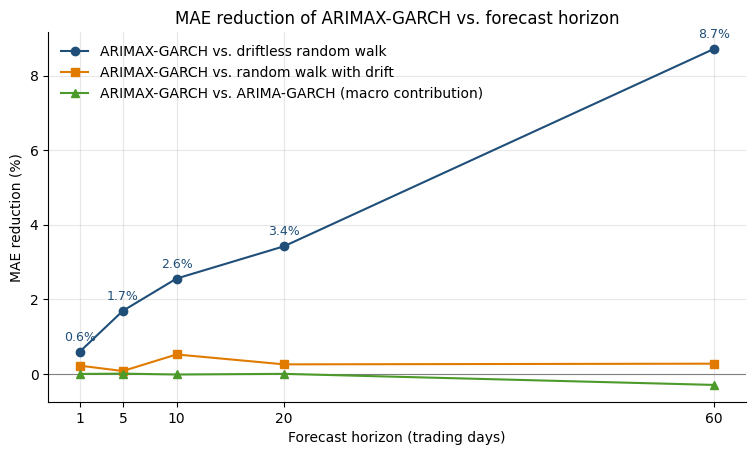

In [ ]:
import numpy as np
# ---------------------------------------------------------------------
# FIGURE 4  ---  MAE reduction of ARIMAX-GARCH vs horizon
# ---------------------------------------------------------------------
C_RW, C_DRIFT, C_MACRO = "#1f4e79", "#e07b00", "#4c9a2a"

# --- Calculation of err_rwd (moved from cell M4GKwXjUEZOI) ---
err_rwd = {h: [] for h in H}
for o in range(WINDOW - 1, n - 1):
    mu = y[o - WINDOW + 1:o + 1].mean()          # mean log-return (%) in window, info <= o
    for h in H:
        if o + h > n - 1:
            continue
        f_rwd = lvl[o] * np.exp(h * mu / 100.0)  # RW-with-drift level forecast
        err_rwd[h].append(lvl[o + h] - f_rwd)
# --------------------------------------------------------------

red_rw, red_rwd, red_ar = [], [], []
for h in H:
    mae_x   = np.mean(np.abs(err["arimax"][h]))
    mae_r   = np.mean(np.abs(err["rw"][h]))
    mae_rwd = np.mean(np.abs(err_rwd[h]))
    mae_a   = np.mean(np.abs(err["arima"][h]))
    red_rw.append(100 * (mae_r - mae_x) / mae_r)
    red_rwd.append(100 * (mae_rwd - mae_x) / mae_rwd)
    red_ar.append(100 * (mae_a - mae_x) / mae_a)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.axhline(0, color="0.5", lw=0.8)
ax.plot(H, red_rw,  "-o", color=C_RW,    label="ARIMAX-GARCH vs. driftless random walk")
ax.plot(H, red_rwd, "-s", color=C_DRIFT, label="ARIMAX-GARCH vs. random walk with drift")
ax.plot(H, red_ar,  "-^", color=C_MACRO, label="ARIMAX-GARCH vs. ARIMA-GARCH (macro contribution)")
for x, v in zip(H, red_rw):                      # anotasi hanya garis atas biar tidak penuh
    ax.annotate(f"{v:.1f}%", (x, v), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9, color=C_RW)
ax.set_title("MAE reduction of ARIMAX-GARCH vs. forecast horizon")
ax.set_xlabel("Forecast horizon (trading days)"); ax.set_ylabel("MAE reduction (%)")
ax.set_xticks(H); ax.legend(frameon=False, loc="best")
ax.grid(True, alpha=0.3); ax.spines[["top", "right"]].set_visible(False)
fig.savefig("figure4_mae_reduction.png", dpi=300, bbox_inches="tight")
print("Figure 4 (three lines) saved.")
print("vs driftless RW :", [round(v,1) for v in red_rw])
print("vs RW-with-drift:", [round(v,1) for v in red_rwd])
print("vs ARIMA (macro):", [round(v,1) for v in red_ar])


#-----------------------------------------------------------------
# 9. 95% interval-forecast evaluation (Figure 5)
Monte Carlo simulation of 2,000 paths per origin. Six models, including a frozen-variance
ARIMAX ablation. Coverage, relative width, interval score, Kupiec and Christoffersen tests.
#-----------------------------------------------------------------

In [40]:
S = 2000; Z = stats.norm.ppf(1 - ALPHA / 2); QLO, QHI = 100 * ALPHA / 2, 100 * (1 - ALPHA / 2)
MODELS = ["rw", "rw_drift", "arima_garch", "arimax_garch", "arimax_frozen", "arimax_ecm_garch"]
band = {m: {h: {"lo": [], "hi": [], "act": []} for h in H} for m in MODELS}
def store(m, h, lo, hi, a): band[m][h]["lo"].append(lo); band[m][h]["hi"].append(hi); band[m][h]["act"].append(a)
def gstate(res, ne):
    p = res.params.to_numpy(); sig = np.asarray(res.conditional_volatility, float); sig = sig[~np.isnan(sig)]
    eps = np.asarray(res.resid, float); eps = eps[~np.isnan(eps)]
    return p[0], p[1], p[2], p[3+ne], p[4+ne], p[5+ne], eps[-1], sig[-1]**2
def sim(o, c, a1, a2, w, al, be, epsT, hT, h, garch=True, fvar=None):
    r1 = np.full(S, y[o]); r2 = np.full(S, y[o-1]); ep = np.full(S, epsT); hv = np.full(S, hT); s = np.zeros(S)
    for _ in range(h):
        hv = w + al*ep**2 + be*hv if garch else np.full(S, fvar)
        ep = np.sqrt(hv) * rng.standard_normal(S); rk = c + a1*r1 + a2*r2 + ep; s += rk; r2, r1 = r1, rk
    return lvl[o] * np.exp(s / 100.0)
def sim_ecm(o, c, a1, a2, lam, w, al, be, epsT, hT, a_ec, b_ec, h):
    r1 = np.full(S, y[o]); r2 = np.full(S, y[o-1]); ep = np.full(S, epsT); hv = np.full(S, hT)
    lp = np.full(S, logp[o]); Weq = a_ec + b_ec @ Wlvl[o]
    for _ in range(h):
        hv = w + al*ep**2 + be*hv; ep = np.sqrt(hv) * rng.standard_normal(S)
        yk = c + a1*r1 + a2*r2 + lam*(lp - Weq) + ep; lp = lp + yk/100.0; r2, r1 = r1, yk
    return np.exp(lp)

for o in range(WINDOW - 1, n - 1):
    tr = slice(o - WINDOW + 1, o + 1); sd = y[tr].std(ddof=1); mu = y[tr].mean()
    for h in H:
        if o + h > n - 1: continue
        store("rw", h, lvl[o]*np.exp(-Z*np.sqrt(h)*sd/100.0), lvl[o]*np.exp(Z*np.sqrt(h)*sd/100.0), lvl[o+h])
        store("rw_drift", h, lvl[o]*np.exp((h*mu-Z*np.sqrt(h)*sd)/100.0), lvl[o]*np.exp((h*mu+Z*np.sqrt(h)*sd)/100.0), lvl[o+h])
    m0 = ARX(y[tr], lags=[1,2], rescale=False); m0.volatility = GARCH(1,0,1); s0 = gstate(m0.fit(disp="off"), 0)
    mx = ARX(y[tr], lags=[1,2], x=Xz[tr], rescale=False); mx.volatility = GARCH(1,0,1); sx = gstate(mx.fit(disp="off"), 3)
    denom = 1 - sx[4] - sx[5]; vun = sx[3]/denom if denom > 1e-6 else np.var(y[tr])
    a_ec, b_ec, zw = fit_ec_term(logp[tr], Wlvl[tr]); zlag = np.empty_like(zw); zlag[0]=0.0; zlag[1:]=zw[:-1]
    ok = True
    try:
        me = ARX(y[tr], lags=[1,2], x=np.column_stack([Xz[tr], zlag]), rescale=False); me.volatility = GARCH(1,0,1)
        pe = me.fit(disp="off"); pp = pe.params.to_numpy(); cE,a1E,a2E,lamE = pp[0],pp[1],pp[2],pp[6]; wE,alE,beE = pp[7],pp[8],pp[9]
        sig = np.asarray(pe.conditional_volatility, float); sig = sig[~np.isnan(sig)]
        rs = np.asarray(pe.resid, float); rs = rs[~np.isnan(rs)]; epE, hTE = rs[-1], sig[-1]**2
    except Exception:
        ok = False
    for h in H:
        if o + h > n - 1: continue
        lo, hi = np.percentile(sim(o, *s0, h, garch=True), [QLO, QHI]); store("arima_garch", h, lo, hi, lvl[o+h])
        lo, hi = np.percentile(sim(o, *sx, h, garch=True), [QLO, QHI]); store("arimax_garch", h, lo, hi, lvl[o+h])
        lo, hi = np.percentile(sim(o, sx[0],sx[1],sx[2],sx[3],sx[4],sx[5],sx[6],sx[7], h, garch=False, fvar=vun), [QLO, QHI])
        store("arimax_frozen", h, lo, hi, lvl[o+h])
        if ok:
            lo, hi = np.percentile(sim_ecm(o, cE,a1E,a2E,lamE,wE,alE,beE,epE,hTE, a_ec, b_ec, h), [QLO, QHI])
        else:
            lo = lvl[o]*np.exp((h*mu-Z*np.sqrt(h)*sd)/100.0); hi = lvl[o]*np.exp((h*mu+Z*np.sqrt(h)*sd)/100.0)
        store("arimax_ecm_garch", h, lo, hi, lvl[o+h])
    if (o - WINDOW + 2) % 200 == 0: print(f"  {o - WINDOW + 2}/{n - WINDOW}")
print("interval simulation done")

  200/1003
  400/1003
  600/1003
  800/1003
  1000/1003
interval simulation done


In [41]:
def interval_score(lo, hi, a, alpha=ALPHA):
    lo, hi, a = map(lambda v: np.asarray(v, float), (lo, hi, a))
    return ((hi - lo) + (2/alpha)*(lo - a)*(a < lo) + (2/alpha)*(a - hi)*(a > hi)).mean()
def kupiec(viol, p=ALPHA):
    viol = np.asarray(viol, int); N = len(viol); x = viol.sum(); pi = x/N
    if x == 0 or x == N: return np.nan
    lr = -2*((N-x)*np.log(1-p)+x*np.log(p)) + 2*((N-x)*np.log(1-pi)+x*np.log(pi))
    return float(1 - stats.chi2.cdf(lr, 1))
def christoffersen(viol, p=ALPHA):
    v = np.asarray(viol, int); n00=n01=n10=n11=0
    for i in range(1, len(v)):
        a, b = v[i-1], v[i]
        n00 += (a==0 and b==0); n01 += (a==0 and b==1); n10 += (a==1 and b==0); n11 += (a==1 and b==1)
    x = v.sum(); N = len(v); pi = x/N
    if x == 0 or x == N: return np.nan
    lr_uc = -2*((N-x)*np.log(1-p)+x*np.log(p)) + 2*((N-x)*np.log(1-pi)+x*np.log(pi))
    pi01 = n01/(n00+n01) if (n00+n01)>0 else 0; pi11 = n11/(n10+n11) if (n10+n11)>0 else 0
    pio = (n01+n11)/(n00+n01+n10+n11)
    def L(pr,k1,k0): return 0.0 if pr<=0 or pr>=1 else k1*np.log(pr)+k0*np.log(1-pr)
    lr_ind = -2*(L(pio,n01+n11,n00+n10) - (L(pi01,n01,n00)+L(pi11,n11,n10)))
    return float(1 - stats.chi2.cdf(lr_uc + lr_ind, 2))

LAB = {"rw":"RW","rw_drift":"RW-drift","arima_garch":"ARIMA-GARCH","arimax_garch":"ARIMAX-GARCH",
       "arimax_frozen":"ARIMAX-frozen","arimax_ecm_garch":"ARIMAX-ECM-GARCH"}
print("=" * 78); print("95% INTERVAL-FORECAST EVALUATION (nominal coverage = 95%)"); print("=" * 78)
for h in H:
    print(f"\nHorizon h = {h}")
    print(f"  {'model':<18}{'cov%':>7}{'width':>9}{'rel%':>8}{'IS':>9}{'Kupiec':>9}{'Christ':>9}")
    for m in MODELS:
        lo = np.array(band[m][h]["lo"]); hi = np.array(band[m][h]["hi"]); a = np.array(band[m][h]["act"])
        viol = ((a < lo) | (a > hi)).astype(int)
        cov = 100*(1 - viol.mean()); width = (hi - lo).mean(); rel = 100*((hi - lo)/a).mean()
        ks = kupiec(viol); cs = christoffersen(viol)
        print(f"  {LAB[m]:<18}{cov:>7.1f}{width:>9.1f}{rel:>8.2f}{interval_score(lo,hi,a):>9.1f}"
              f"{ks:>9.3f}{cs:>9.3f}")

95% INTERVAL-FORECAST EVALUATION (nominal coverage = 95%)

Horizon h = 1
  model                cov%    width    rel%       IS   Kupiec   Christ
  RW                   95.5    241.9    1.52    317.5    0.448    0.128
  RW-drift             95.5    241.9    1.52    318.1    0.448    0.128
  ARIMA-GARCH          94.5    212.5    1.34    292.1    0.489    0.423
  ARIMAX-GARCH         94.3    211.5    1.33    293.6    0.331    0.377
  ARIMAX-frozen        95.5    238.9    1.50    313.1    0.448    0.010
  ARIMAX-ECM-GARCH     94.4    211.6    1.33    294.5    0.405    0.546

Horizon h = 5
  model                cov%    width    rel%       IS   Kupiec   Christ
  RW                   95.3    540.9    3.41    697.4    0.665    0.000
  RW-drift             95.4    541.2    3.41    701.7    0.561    0.000
  ARIMA-GARCH          93.8    516.2    3.25    701.2    0.091    0.000
  ARIMAX-GARCH         93.7    515.4    3.24    701.7    0.068    0.000
  ARIMAX-frozen        96.2    569.8    3.59    

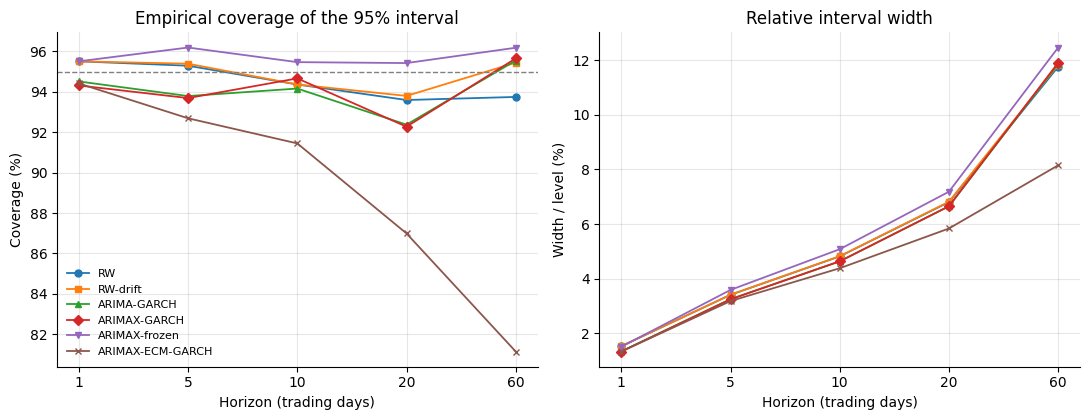

In [42]:
# Figure 5: interval coverage and relative width by horizon
order = ["rw","rw_drift","arima_garch","arimax_garch","arimax_frozen","arimax_ecm_garch"]
mk = {"rw":"o","rw_drift":"s","arima_garch":"^","arimax_garch":"D","arimax_frozen":"v","arimax_ecm_garch":"x"}
cov, relw = {}, {}
for m in order:
    cov[m], relw[m] = [], []
    for h in H:
        lo = np.array(band[m][h]["lo"]); hi = np.array(band[m][h]["hi"]); a = np.array(band[m][h]["act"])
        v = ((a < lo) | (a > hi)).astype(int)
        cov[m].append(100*(1 - v.mean())); relw[m].append(100*((hi - lo)/a).mean())
x = np.arange(len(H)); fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
for m in order:
    a1.plot(x, cov[m], marker=mk[m], lw=1.3, ms=5, label=LAB[m])
    a2.plot(x, relw[m], marker=mk[m], lw=1.3, ms=5, label=LAB[m])
a1.axhline(95, ls="--", color="0.5", lw=1)
a1.set_title("Empirical coverage of the 95% interval"); a1.set_ylabel("Coverage (%)")
a2.set_title("Relative interval width"); a2.set_ylabel("Width / level (%)")
for ax in (a1, a2):
    ax.set_xticks(x); ax.set_xticklabels(H); ax.set_xlabel("Horizon (trading days)")
    ax.grid(True, alpha=0.3); ax.spines[["top","right"]].set_visible(False)
a1.legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout(); fig.savefig("figure5.png", dpi=200, bbox_inches="tight"); plt.show()

# =========================================================
# 10. Data and results figures (Figures 1-4)
# =========================================================

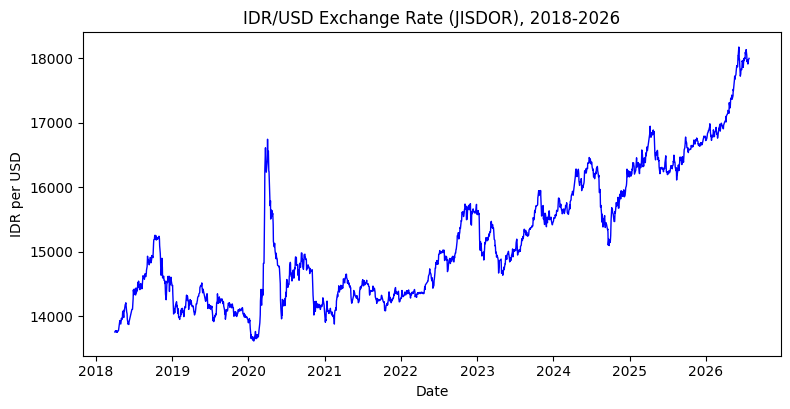

In [43]:
# Figure 1: level of the exchange rate
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(df.index, df["fx"], color="blue", lw=1.0)
ax.set_title("IDR/USD Exchange Rate (JISDOR), 2018-2026")
ax.set_xlabel("Date"); ax.set_ylabel("IDR per USD")
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.savefig("figure1.png", dpi=200); plt.show()

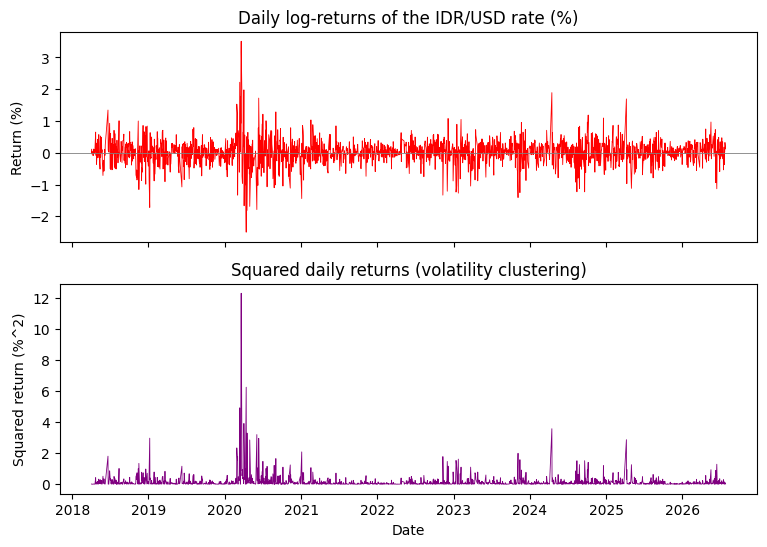

In [44]:
# Figure 2: daily log-returns and squared returns (volatility clustering)
dates = data.index
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
a1.plot(dates, y, color="red", lw=0.6); a1.axhline(0, color="0.5", lw=0.6)
a1.set_title("Daily log-returns of the IDR/USD rate (%)"); a1.set_ylabel("Return (%)")
a2.plot(dates, y**2, color="purple", lw=0.6)
a2.set_title("Squared daily returns (volatility clustering)"); a2.set_ylabel("Squared return (%^2)"); a2.set_xlabel("Date")
a2.xaxis.set_major_locator(mdates.YearLocator()); a2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.savefig("figure2.png", dpi=200); plt.show()

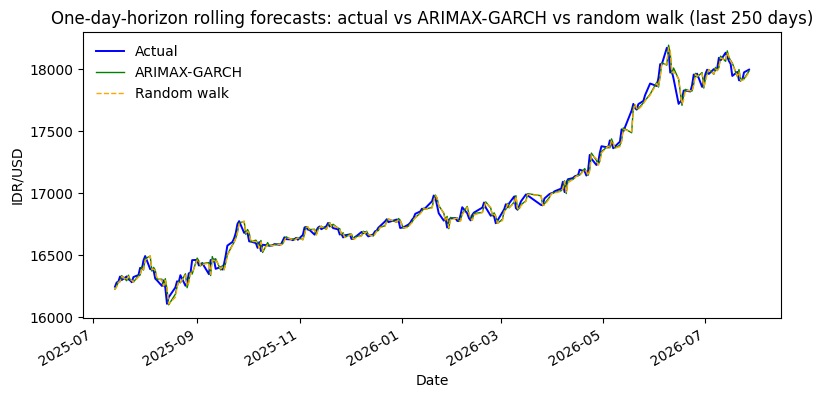

In [45]:
# Figure 3: last 250 one-day-ahead forecasts, actual vs ARIMAX-GARCH vs RW
f3_idx = list(range(WINDOW, n))
f3_actual = np.array(act[1]); f3_arimax = np.array(act[1]) - np.array(err["arimax"][1]); f3_rw = np.array(act[1]) - np.array(err["rw"][1])
k = min(250, len(f3_idx)); sel = slice(len(f3_idx) - k, len(f3_idx)); d3 = data.index[np.array(f3_idx)[sel]]
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(d3, np.array(f3_actual)[sel], color="blue", lw=1.4, label="Actual")
ax.plot(d3, np.array(f3_arimax)[sel], color="green", lw=1.0, label="ARIMAX-GARCH")
ax.plot(d3, np.array(f3_rw)[sel], color="orange", lw=1.0, ls="--", label="Random walk")
ax.set_title("One-day-horizon rolling forecasts: actual vs ARIMAX-GARCH vs random walk (last 250 days)")
ax.set_xlabel("Date"); ax.set_ylabel("IDR/USD"); ax.legend(frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m")); fig.autofmt_xdate()
fig.savefig("figure3.png", dpi=200); plt.show()

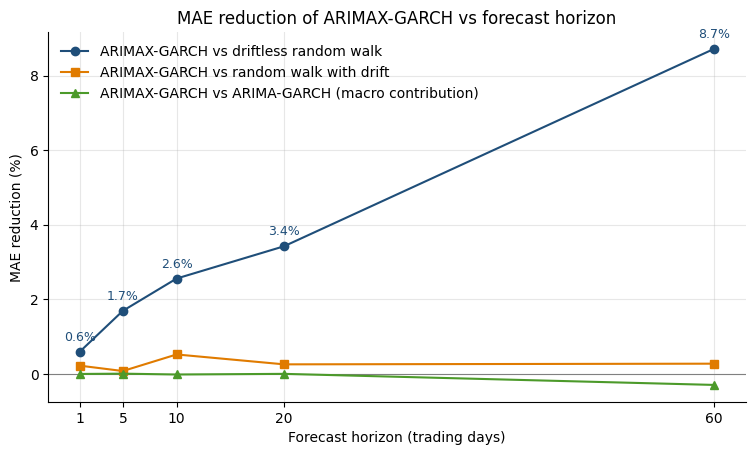

In [46]:
# Figure 4: MAE reduction of ARIMAX-GARCH vs three benchmarks by horizon
red_rw, red_rwd, red_ar = [], [], []
for h in H:
    a = np.asarray(act[h], float)
    mae_x = np.mean(np.abs(err["arimax"][h])); mae_r = np.mean(np.abs(err["rw"][h]))
    mae_rwd = np.mean(np.abs(err["rw_drift"][h])); mae_a = np.mean(np.abs(err["arima"][h]))
    red_rw.append(100*(mae_r-mae_x)/mae_r); red_rwd.append(100*(mae_rwd-mae_x)/mae_rwd); red_ar.append(100*(mae_a-mae_x)/mae_a)
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.axhline(0, color="0.5", lw=0.8)
ax.plot(H, red_rw, "-o", color="#1f4e79", label="ARIMAX-GARCH vs driftless random walk")
ax.plot(H, red_rwd, "-s", color="#e07b00", label="ARIMAX-GARCH vs random walk with drift")
ax.plot(H, red_ar, "-^", color="#4c9a2a", label="ARIMAX-GARCH vs ARIMA-GARCH (macro contribution)")
for xv, vv in zip(H, red_rw):
    ax.annotate(f"{vv:.1f}%", (xv, vv), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9, color="#1f4e79")
ax.set_title("MAE reduction of ARIMAX-GARCH vs forecast horizon")
ax.set_xlabel("Forecast horizon (trading days)"); ax.set_ylabel("MAE reduction (%)")
ax.set_xticks(H); ax.legend(frameon=False, loc="best"); ax.grid(True, alpha=0.3); ax.spines[["top","right"]].set_visible(False)
fig.savefig("figure4.png", dpi=200, bbox_inches="tight"); plt.show()